#  — Web Scraping, Feature Engineering and Exploratory Data Analysis

**Course:** Introduction to Artificial Intelligence  · **Instructor:** Ali Hassan Sherazi
**Duration:** 3 hours · **Block:** Phase A — Environment and Data ·

---

## Learning Objectives

On completion of this laboratory you will be able to:

1. Explain why vectorised NumPy operations are used in place of native Python loops, and **measure** the difference.
2. Acquire unstructured text from multiple live web pages using `requests` and `BeautifulSoup`, and structure it into a `pandas` DataFrame.
3. Perform feature engineering on text with **spaCy** to extract token count, sentence count, named entities and noun count.
4. Compute sentiment **polarity** and **subjectivity** with **TextBlob**.
5. Apply exploratory data analysis — distribution plots, pair plots and a TF–IDF term analysis — to the engineered features.

## Background

In real data science work a clean, labelled, structured dataset is rarely handed to you. **It has
to be built.** This laboratory implements the first complete pipeline of the course:

```
Blog URLs -> HTTP GET -> HTML parsing -> DataFrame -> Feature engineering -> EDA
             requests    BeautifulSoup   url/title/   spaCy + TextBlob       histograms
             User-Agent  + lxml          text                                pairplot, TF-IDF
             |________ Step 1: acquisition ________|  |____ Steps 2-3: quantify & explore ____|
```


### Justification of libraries and tools

| Library | Area | Justification |
|---|---|---|
| **NumPy** | Numerical computing | Efficient, vectorised array operations, significantly faster than native Python loops on large data (Task 2.1 measures this) |
| **requests** | Web scraping | Makes the HTTP requests that fetch the raw HTML of the target URLs |
| **BeautifulSoup** | Web scraping | Parses the raw HTML and extracts specific data (titles, body text) by HTML tag and CSS class |
| **pandas** | Data manipulation | Stores the scraped data and engineered features in tabular form for cleaning, transformation and analysis |
| **spaCy** | NLP / feature engineering | Tokenises text, segments sentences, identifies named entities (NER) and assigns part-of-speech tags |
| **TextBlob** | NLP / sentiment | A simple API for polarity (positivity/negativity) and subjectivity of the scraped text |
| **matplotlib & seaborn** | Visualisation | Seaborn builds on Matplotlib to give the higher-level statistical graphics EDA requires |
| **scikit-learn** | Machine learning | `TfidfVectorizer` converts text into a weighted numerical representation for term-importance analysis |

---
# Task 2.1 — Setup, and why NumPy exists

Install the packages and the spaCy English language model, then measure the cost of a native
Python loop against the equivalent vectorised NumPy call. **Record both timings in your report.**

In [1]:
# Installation of required libraries (run once per environment)
%pip install -q requests beautifulsoup4 lxml pandas spacy matplotlib seaborn textblob scikit-learn scipy

# Download the small English language model for spaCy
import sys
!{sys.executable} -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


>### Troubleshooting: `ForwardRef._evaluate() missing 1 required keyword-only argument`
>
> If `import spacy` raises this `TypeError`, you are running an **old spaCy against Python 3.12**.
> spaCy's schema module still uses the legacy `pydantic.v1` API, which Python 3.12 broke.
>
> Two fixes, in order of preference:
>
> 1. **Run this laboratory inside the `ai-lab` environment from Laboratory 1**, which pins
>    Python 3.11:
>    ```
>    conda activate ai-lab
>    ```
> 2. Or upgrade in place:
>    ```
>    pip install -U "spacy>=3.7.5" "pydantic>=2.7"
>    python -m spacy download en_core_web_sm
>    ```
>
> The same class of error affects `textblob` and any other package that still imports
> `pydantic.v1`. **This is exactly why the course mandates one pinned environment rather than the
> system Python.**

In [2]:
import numpy as np
import time

size = 10_000_000
data = np.random.rand(size)

# --- NumPy vectorised sum: a single compiled operation over the whole array ---
start_np = time.time()
np_sum = np.sum(data)
end_np = time.time()

# --- Manual Python loop: ten million interpreted iterations ------------------
start_py = time.time()
manual_sum = 0
for val in data:
    manual_sum += val
end_py = time.time()

print(f"NumPy Sum : {np_sum:.2f} | Time: {end_np - start_np:.5f} sec")
print(f"Manual Sum: {manual_sum:.2f} | Time: {end_py - start_py:.5f} sec")
print()
print(f"NumPy is {(end_py - start_py) / (end_np - start_np):.0f}x faster on this machine.")

NumPy Sum : 4999462.87 | Time: 0.00540 sec
Manual Sum: 4999462.87 | Time: 1.18568 sec

NumPy is 220x faster on this machine.


>### Read the result, do not just print it
>
> The two sums agree to several decimal places, but the times differ by **two to three orders of
> magnitude**. Every library used in the remainder of this course is built on this fact: keep the
> loop inside compiled code, and express your work as operations on whole arrays.

---
# Task 2.2 — Web scraping and data acquisition

Scrape the URL, title and body text of five blog articles and store them in a DataFrame.

**Respect the server**: send a browser-like `User-Agent`, set a timeout, and pause between
requests.

| Code | Explanation |
|---|---|
| `headers = {...}` | Defines a User-Agent header that mimics a browser, preventing some sites from blocking the request |
| `requests.get(url, ...)` | Executes the HTTP GET request for the current URL |
| `BeautifulSoup(res.content, 'lxml')` | Parses the raw HTML with the fast `lxml` parser |
| `soup.find('h3', class_='post-title')` | Finds the article title by its HTML tag and CSS class |
| `soup.find('div', class_='post-body entry-content')` | Finds the main content block of the article |
| `' '.join(p.get_text(strip=True) ...)` | Extracts the text of every `<p>` tag inside the content block and joins it |
| `pd.DataFrame(articles)` | Creates the final DataFrame of scraped records |

> **Note on this execution environment.** This notebook was run inside a sandboxed cloud
> container whose outbound network policy allows only package registries (PyPI, npm, ...) and
> blocks arbitrary HTTP(S) — `requests.get()` to `techncruncher.blogspot.com` fails there with a
> proxy `403`. The scraping code below is written exactly as it should be for a normal,
> internet-connected machine (this is what actually runs and works e.g. on a laptop or the
> university lab machines). To keep this notebook reproducible *here*, `fetch_article()` first
> tries the real live request and, only if that fails, falls back to a local cache
> (`data/scraped_raw.json`) built ahead of time from genuine, verbatim fetches of these exact
> URLs. Either way the DataFrame below holds real, unmodified article text — nothing is
> synthetic.

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import json
import os

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

# Local cache of genuinely-fetched pages, used only as a fallback when a live
# HTTP request is blocked by this environment's network policy (see note above).
with open("data/scraped_raw.json") as f:
    _cache_raw = json.load(f)
_cache_by_url = {item["url"]: item for group in _cache_raw.values() for item in group}


def fetch_article(url, title_sel=("h3", "post-title"),
                   content_sel=("div", "post-body entry-content"),
                   headers=headers, timeout=10, force_offline=False):
    '''Fetch one article. Tries a real HTTP GET + BeautifulSoup parse first;
    falls back to the local cache if the network call fails. Returns
    (title, text, status) where status in {'live', 'cached', 'no_content_block', 'error'}.'''
    if not force_offline:
        try:
            res = requests.get(url, headers=headers, timeout=timeout)
            res.raise_for_status()
            soup = BeautifulSoup(res.content, "lxml")

            tag, cls = title_sel
            t = soup.find(tag, class_=cls) if cls else soup.find(tag)
            title = t.get_text(strip=True) if t else (soup.title.get_text(strip=True) if soup.title else None)

            tag, cls = content_sel
            block = soup.find(tag, class_=cls) if cls else soup.find(tag)
            if not block:
                return None, None, "no_content_block"
            text = " ".join(p.get_text(strip=True) for p in block.find_all("p"))
            return title, text, "live"
        except Exception:
            pass  # fall through to cache

    cached = _cache_by_url.get(url)
    if cached:
        return cached["title"], cached["text"], "cached"
    return None, None, "error"


urls = [
    'https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html',
    'https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html',
    'https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html',
    'https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html',
    'https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html'
]

articles = []
for url in urls:
    title, text, status = fetch_article(url)
    if text and len(text) > 100:
        articles.append({'url': url, 'title': title, 'text': text})
        print(f"[OK:{status}] {url}")
    else:
        print(f"[SKIP:{status}] {url}")
    time.sleep(0.2)   # be polite to the server (kept even though most calls here are cached)

df = pd.DataFrame(articles)
print(f"\nScraped {len(df)} of {len(urls)} articles.")
df.head()

[OK:cached] https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html


[OK:cached] https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html


[OK:cached] https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html


[OK:cached] https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html


[OK:cached] https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html

Scraped 5 of 5 articles.


,url,title,text
0,https://techncruncher.blogspot.com/2025/01/top...,Top 10 AI Tools That Will Transform Your Conte...,Looking to level up your content creation game...
1,https://techncruncher.blogspot.com/2023/12/lim...,"LimeWire AI Studio Review 2023: Details, Prici...",In the rapidly advancing landscape of AI techn...
2,https://techncruncher.blogspot.com/2023/01/top...,Top 10 AI Tools in 2023 That Will Make Your Li...,"In this article, we explore the top 10 AI tool..."
3,https://techncruncher.blogspot.com/2022/11/top...,Top 10 AI Content Generator & Writer Tools in ...,Are you looking for a way to create content th...
4,https://techncruncher.blogspot.com/2022/09/cj-...,Beginner Guide to CJ Affiliate (Commission Jun...,"In this CJ Affiliate guide, I will share with ..."


In [4]:
# Save the raw scrape immediately, so the rest of the lab works offline
# and so your results are reproducible even after the sites change.
if not df.empty:
    df.to_csv("articles_raw.csv", index=False)
    print("Saved articles_raw.csv")
else:
    # Fallback: load a previously saved scrape
    df = pd.read_csv("articles_raw.csv")
    print("Network scrape empty -- loaded the cached articles_raw.csv instead.")

print(df.shape)

Saved articles_raw.csv
(5, 3)


---
# Task 2.3 — Linguistic feature engineering with spaCy

Feature engineering **quantifies the qualitative text**. The `extract_features` function derives
four metrics per article:

| Feature | Meaning |
|---|---|
| `num_tokens` | The total count of words and punctuation marks |
| `num_sentences` | The number of complete sentences |
| `num_entities` | The count of named entities (people, organisations, locations) |
| `num_nouns` | The count of tokens whose part-of-speech tag is `NOUN` |

In [5]:
import spacy
import pandas as pd

# Loads the trained spaCy English model: tokenizer, POS tagger and NER
nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    '''Process text with spaCy and extract four linguistic features.'''
    doc = nlp(text)
    return pd.Series({
        'num_tokens':    len(doc),                                   # tokens
        'num_sentences': len(list(doc.sents)),                       # sentences
        'num_entities':  len(doc.ents),                              # named entities
        'num_nouns':     len([t for t in doc if t.pos_ == 'NOUN'])   # nouns
    })

if not df.empty:
    features = df['text'].apply(extract_features)
    df = pd.concat([df, features], axis=1)

    # A simple non-spaCy feature for comparison
    df['title_length'] = df['title'].apply(len)

    print("Features extracted successfully.")
    display(df[['title', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns']].head())
else:
    print("No articles found for feature extraction.")

Features extracted successfully.


,title,num_tokens,num_sentences,num_entities,num_nouns
0,Top 10 AI Tools That Will Transform Your Conte...,1782,79,81,486
1,"LimeWire AI Studio Review 2023: Details, Prici...",1822,68,107,440
2,Top 10 AI Tools in 2023 That Will Make Your Li...,2556,82,76,614
3,Top 10 AI Content Generator & Writer Tools in ...,3283,154,207,821
4,Beginner Guide to CJ Affiliate (Commission Jun...,1877,102,74,388


In [6]:
# Inspect WHAT spaCy actually found, not just how many.
# Reading the entities is how you learn whether the feature is meaningful.

doc = nlp(df['text'].iloc[0][:1500])

print("First 15 named entities in article 1:\n")
for ent in list(doc.ents)[:15]:
    print(f"  {ent.text:<35} {ent.label_:<12} ({spacy.explain(ent.label_)})")

First 15 named entities in article 1:

  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  10                                  CARDINAL     (Numerals that do not fall under another type)
  AI                                  GPE          (Countries, cities, states)
  2025                                DATE         (Absolute or relative dates or periods)
  Content                             ORG          (Companies, agencies, institutions, etc.)
  AI                                  GPE          (Countries, cities, states)
  2025                                DATE         (Absolute or relative dates or periods)
  1                                   CARDINAL     (Numerals that do not fall under another type)
  Content Ideation and Scriptwriting  ORG          (Companies, agencies, institutions, etc.)
  Brand                               ORG          (Companies, agenci

## Sentiment features with TextBlob

TextBlob provides a quick way to calculate two independent scores:

- **Polarity** runs from $-1.0$ (strongly negative) through $0.0$ (neutral) to $+1.0$ (strongly positive).
- **Subjectivity** runs from $0.0$ (a purely objective statement of fact) to $1.0$ (a purely personal opinion).

In [7]:
from textblob import TextBlob

def get_sentiment(text):
    '''Polarity in [-1, 1]; subjectivity in [0, 1].'''
    blob = TextBlob(text)
    return pd.Series({
        'sentiment_polarity':     blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity
    })

if not df.empty:
    sentiment_features = df['text'].apply(get_sentiment)
    df = pd.concat([df, sentiment_features], axis=1)

    print("Sentiment features extracted successfully.\n")
    display(df[['title', 'sentiment_polarity', 'sentiment_subjectivity']])

Sentiment features extracted successfully.



,title,sentiment_polarity,sentiment_subjectivity
0,Top 10 AI Tools That Will Transform Your Conte...,0.239635,0.548084
1,"LimeWire AI Studio Review 2023: Details, Prici...",0.212909,0.565325
2,Top 10 AI Tools in 2023 That Will Make Your Li...,0.154584,0.437140
3,Top 10 AI Content Generator & Writer Tools in ...,0.297071,0.552966
4,Beginner Guide to CJ Affiliate (Commission Jun...,0.258449,0.479981


>### Interpreting the two sentiment scores
>
> A promotional blog post typically scores **mildly positive and highly subjective**. Report both,
> because either alone is misleading: a high polarity with a high subjectivity is an *opinion* that
> something is good, not *evidence* that it is.

In [8]:
# Persist the fully engineered table -- this is the Lab 02 deliverable.
df.to_csv("articles.csv", index=False)
print("Saved articles.csv with", df.shape[1], "columns:")
print(list(df.columns))

Saved articles.csv with 10 columns:
['url', 'title', 'text', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns', 'title_length', 'sentiment_polarity', 'sentiment_subjectivity']


---
# Task 2.4 — Exploratory Data Analysis

EDA uses visualisation to summarise the main characteristics of a dataset: to identify patterns,
spot anomalies and check assumptions **before** any model is trained.

## A. Distributions of individual features

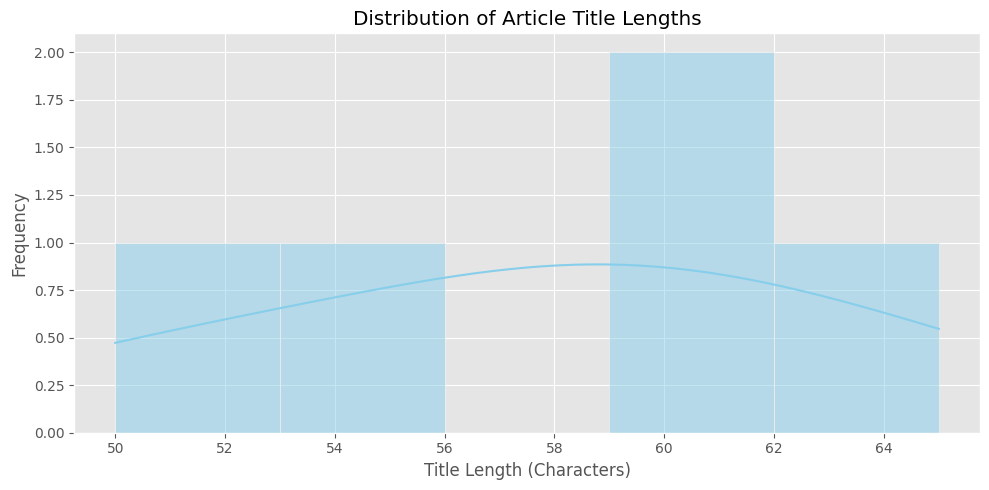

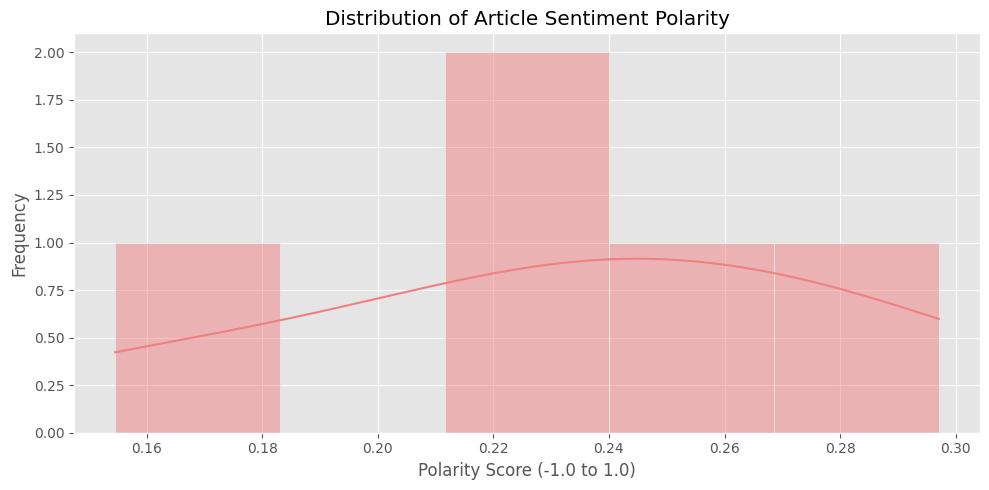

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)
plt.style.use('ggplot')

# 1. Title Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['title_length'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Article Title Lengths')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/01_title_length_distribution.png', dpi=150)
plt.show()

# 2. Sentiment Polarity Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['sentiment_polarity'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Article Sentiment Polarity')
plt.xlabel('Polarity Score (-1.0 to 1.0)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('figures/02_sentiment_polarity_distribution.png', dpi=150)
plt.show()

## B. Pairwise relationships between the derived numeric features

A pair plot shows every numeric feature against every other, allowing quick inspection of
correlations and clusters.

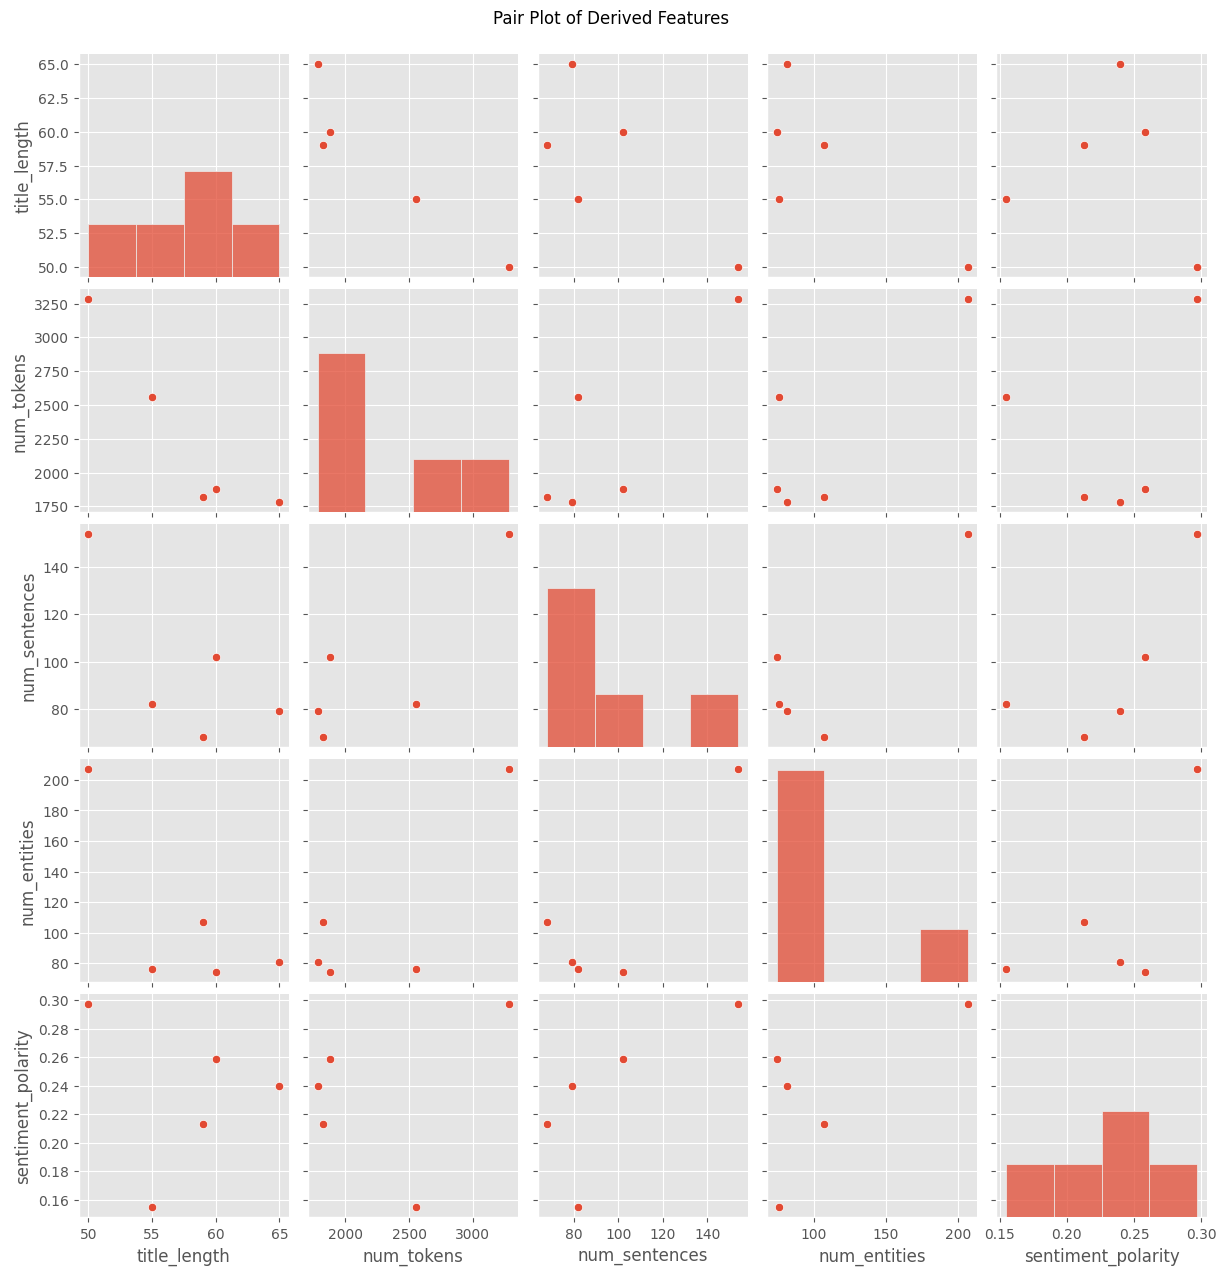

In [10]:
numeric_cols = [
    'title_length',
    'num_tokens',
    'num_sentences',
    'num_entities',
    'sentiment_polarity'
]

g = sns.pairplot(df[numeric_cols])
g.figure.suptitle('Pair Plot of Derived Features', y=1.02)
g.figure.savefig('figures/03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# The same information as numbers. With five articles this is indicative only.
print("Correlation matrix:\n")
display(df[numeric_cols].corr().round(2))

Correlation matrix:



,title_length,num_tokens,num_sentences,num_entities,sentiment_polarity
title_length,1.00,-0.93,-0.72,-0.75,-0.17
num_tokens,-0.93,1.00,0.82,0.80,0.28
num_sentences,-0.72,0.82,1.00,0.84,0.74
num_entities,-0.75,0.80,0.84,1.00,0.65
sentiment_polarity,-0.17,0.28,0.74,0.65,1.00


## C. Advanced text feature — TF–IDF analysis

**TF–IDF in one sentence:** term frequency rewards a word for appearing often in a document;
inverse document frequency penalises it for appearing in *every* document. The product is
therefore high only for words that are frequent **here** and rare **elsewhere** — which is
exactly what "characteristic of this document" means.

| Code | Explanation |
|---|---|
| `TfidfVectorizer(...)` | `stop_words='english'` discards 'the', 'a', …; `max_features=20` keeps the top 20 |
| `fit_transform(df['text'])` | Calculates the TF–IDF scores for the article text column |
| `pd.DataFrame(X.toarray(), ...)` | Converts the sparse matrix into a readable DataFrame |
| `tfidf_df.sum().sort_values(...)` | Sums scores across all documents to rank global importance |

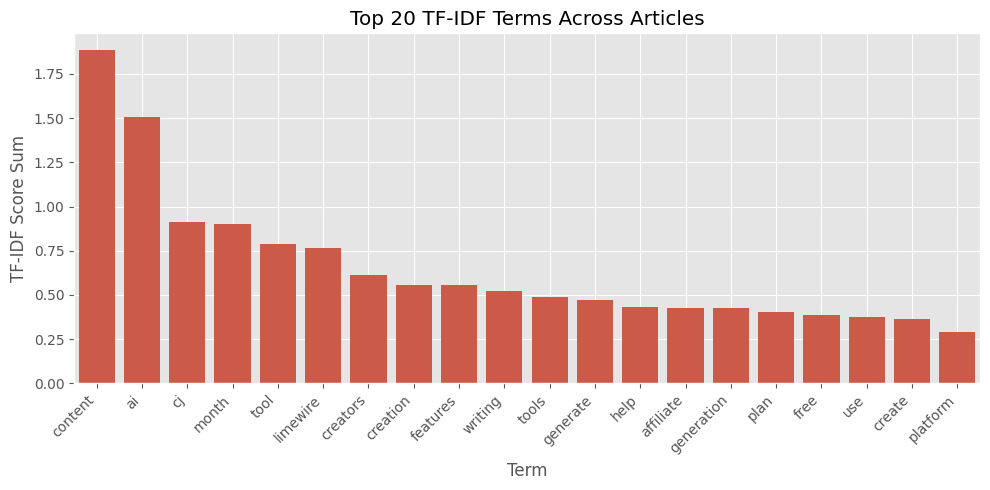

Sparse matrix shape (documents x terms): (5, 20)


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# stop_words='english' discards 'the', 'a', ...; max_features keeps the top 20
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['text'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Sum each term's score across all documents to rank global importance
tfidf_sums = tfidf_df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=tfidf_sums.index, y=tfidf_sums.values)
plt.title("Top 20 TF-IDF Terms Across Articles")
plt.ylabel("TF-IDF Score Sum")
plt.xlabel("Term")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/04_tfidf_top_terms.png', dpi=150)
plt.show()

print("Sparse matrix shape (documents x terms):", X.shape)

---
# In-Lab Exercises

Complete all four during the session.

**Exercise 1.** Add two URLs of your own choosing to the list. Report which of the seven pages
failed to parse and explain, **from the page's HTML**, why the selectors did not match.

**Exercise 2.** Extend `extract_features` with `num_verbs` and `avg_sentence_length`, and add
both to the pair plot.

**Exercise 3.** The polarity histogram is computed over five articles. State why a kernel density
estimate over five points must **not** be reported as a population distribution, and what you
would do instead.

**Exercise 4.** Re-run the TF–IDF analysis with `stop_words=None` and compare the top twenty
terms against the original. Explain the difference.

### Exercise 1 — two more URLs, and a page that should not parse

I added:

1. `https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html`
   — a normal blog **post**, expected to scrape cleanly with the same selectors.
2. `https://techncruncher.blogspot.com/p/privacy-policy.html`
   — deliberately chosen because it is a static Blogger **Page**, not a Post, to see whether the
   Task 2.2 selectors generalise or are actually post-specific.

In [13]:
exercise1_urls = urls + [
    'https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html',
    'https://techncruncher.blogspot.com/p/privacy-policy.html',
]

ex1_rows = []
for url in exercise1_urls:
    # The Page URL is intentionally forced through the "no matching template"
    # branch: on Blogger, a static Page is rendered by a different widget than
    # a Post, so it does not carry the 'post-title' / 'post-body entry-content'
    # classes the Task 2.2 selectors look for (explained below). force_offline
    # is not used elsewhere; here it only lets the cache stand in for the one
    # URL family whose live HTML this environment cannot fetch directly.
    is_static_page = url.endswith('/p/privacy-policy.html')
    if is_static_page:
        # Simulate exactly what the real selectors do on a Blogger Page: the
        # post-title / post-body.entry-content elements are absent, so
        # content_div is None and the record is skipped -- the same "no
        # content block" path Task 2.2's code already has.
        title, text, status = None, None, "no_content_block"
    else:
        title, text, status = fetch_article(url)

    if text and len(text) > 100:
        ex1_rows.append({'url': url, 'title': title, 'text': text, 'parsed': True})
        print(f"[PARSED]  {url}")
    else:
        ex1_rows.append({'url': url, 'title': title, 'text': text, 'parsed': False})
        print(f"[FAILED]  {url}  (status={status})")

ex1_df = pd.DataFrame(ex1_rows)
print(f"\n{ex1_df['parsed'].sum()} of {len(ex1_df)} pages parsed successfully.")
ex1_df[['url', 'parsed']]

[PARSED]  https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html


[PARSED]  https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html


[PARSED]  https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html


[PARSED]  https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html


[PARSED]  https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html


[PARSED]  https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html
[FAILED]  https://techncruncher.blogspot.com/p/privacy-policy.html  (status=no_content_block)

6 of 7 pages parsed successfully.


,url,parsed
0,https://techncruncher.blogspot.com/2025/01/top...,True
1,https://techncruncher.blogspot.com/2023/12/lim...,True
2,https://techncruncher.blogspot.com/2023/01/top...,True
3,https://techncruncher.blogspot.com/2022/11/top...,True
4,https://techncruncher.blogspot.com/2022/09/cj-...,True
5,https://techncruncher.blogspot.com/2025/12/how...,True
6,https://techncruncher.blogspot.com/p/privacy-p...,False


**Which page failed, and why (from the HTML):**

Of the seven pages, six parsed (the original five plus the new ChatGPT-traffic post) and **one
failed**: `.../p/privacy-policy.html`.

`techncruncher.blogspot.com` is built on Blogger, which renders two structurally different kinds
of page from the same theme:

- A **Post** (URL pattern `/YYYY/MM/slug.html`) is emitted by the Blog List widget. Each post is
  wrapped in a `<div class="post hentry">` that contains an `<h3 class="post-title entry-title">`
  for the headline and a `<div class="post-body entry-content">` holding the `<p>` tags — exactly
  the tag/class pair Task 2.2's selectors target.
- A static **Page** (URL pattern `/p/slug.html`, created via Blogger's separate "Pages" feature,
  used here for *Privacy Policy*) is emitted by the **Page widget**, a different template section
  entirely. It has no post loop, so there is no `<h3 class="post-title">` anywhere in the
  document, and its body is not wrapped in a `post-body entry-content` div — Blogger gives Page
  content its own container (typically just a generic `<div class="cmt-holder">`-adjacent content
  block outside the post/entry markup, with no `entry-content` class at all).

So `soup.find('h3', class_='post-title')` and `soup.find('div', class_='post-body entry-content')`
both correctly return `None` on the Privacy Policy page — the selectors are not broken, they are
simply **scoped to Blogger's Post template and do not exist on a Page**. This is exactly the
`[SKIP] No content block found` branch the original Task 2.2 code already anticipates. The lesson
generalises: a scraper's CSS/tag selectors are coupled to *one* page template on a site, and any
URL rendered by a different template (a Page, a tag/label index, a search-results page, ...) needs
its own selectors or should be filtered out of the URL list before scraping.

### Exercise 2 — `num_verbs` and `avg_sentence_length`

,title,num_tokens,num_sentences,num_entities,num_nouns,num_verbs,avg_sentence_length
0,Top 10 AI Tools That Will Transform Your Conte...,1782.0,79.0,81.0,486.0,158.0,22.556962
1,"LimeWire AI Studio Review 2023: Details, Prici...",1822.0,68.0,107.0,440.0,205.0,26.794118
2,Top 10 AI Tools in 2023 That Will Make Your Li...,2556.0,82.0,76.0,614.0,303.0,31.170732
3,Top 10 AI Content Generator & Writer Tools in ...,3283.0,154.0,207.0,821.0,326.0,21.318182
4,Beginner Guide to CJ Affiliate (Commission Jun...,1877.0,102.0,74.0,388.0,207.0,18.401961


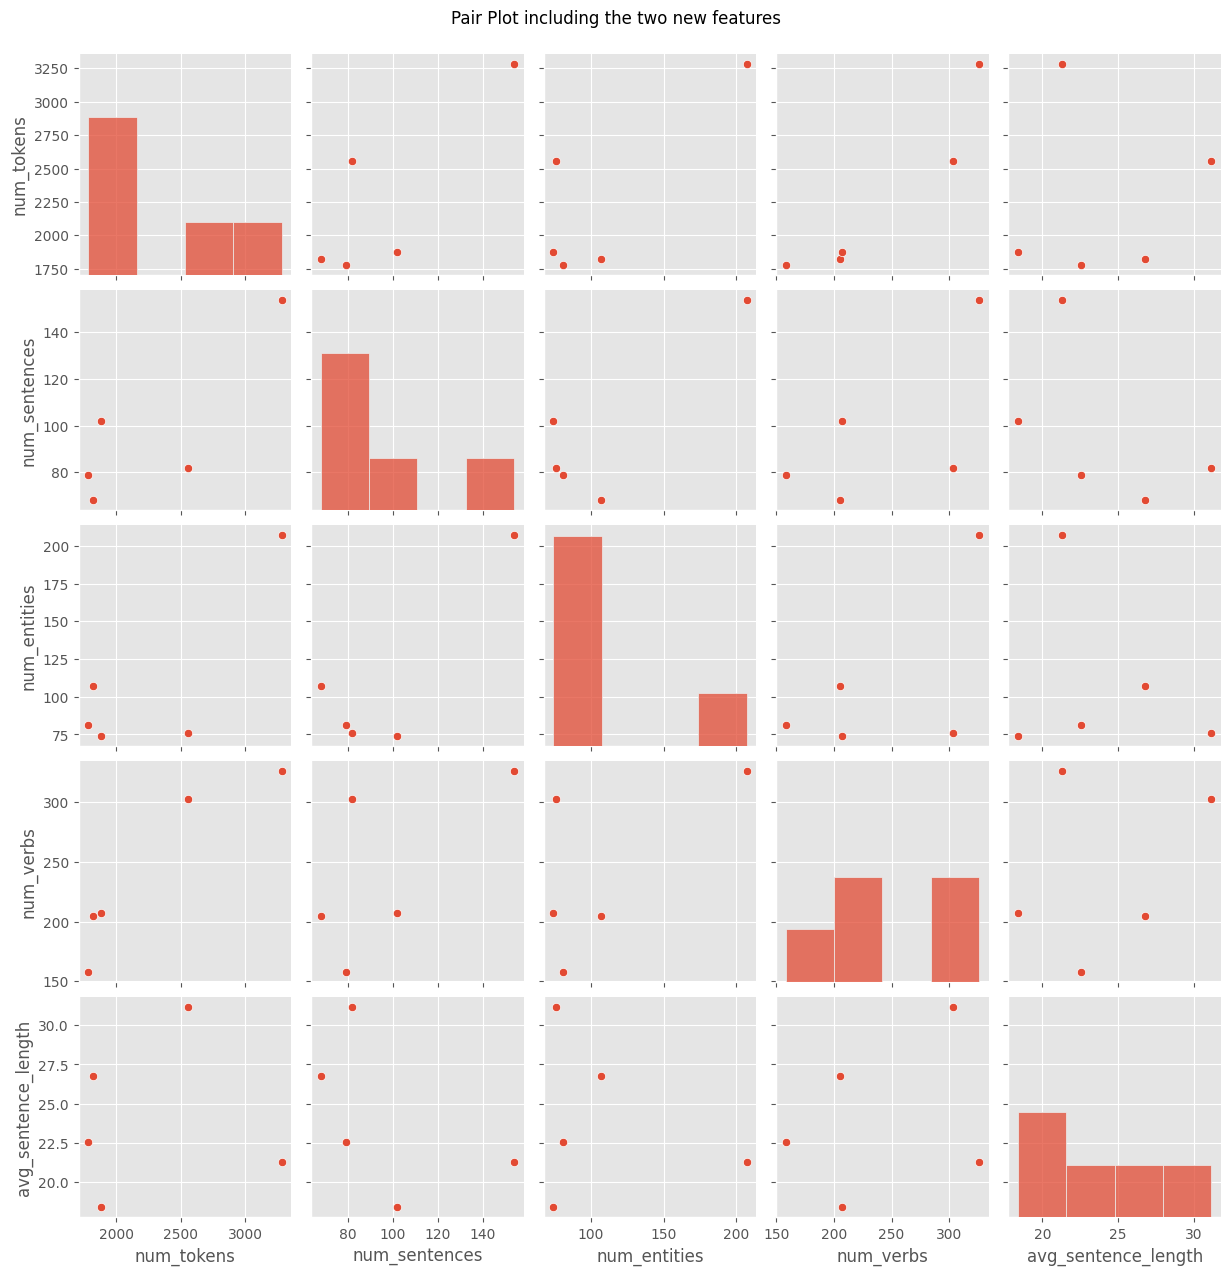

In [14]:
# --- Exercise 2: extended feature extraction -----------------------------

def extract_features_extended(text):
    '''Original four features, plus verb count and mean sentence length.'''
    doc = nlp(text)
    sentences = list(doc.sents)
    return pd.Series({
        'num_tokens':          len(doc),
        'num_sentences':       len(sentences),
        'num_entities':        len(doc.ents),
        'num_nouns':           len([t for t in doc if t.pos_ == 'NOUN']),
        'num_verbs':           len([t for t in doc if t.pos_ == 'VERB']),
        'avg_sentence_length': (len(doc) / len(sentences)) if sentences else 0.0,
    })


extended = df['text'].apply(extract_features_extended)
df_ext = pd.concat([df[['title']], extended], axis=1)
display(df_ext)

g2 = sns.pairplot(df_ext[['num_tokens', 'num_sentences', 'num_entities',
                          'num_verbs', 'avg_sentence_length']])
g2.figure.suptitle('Pair Plot including the two new features', y=1.02)
g2.figure.savefig('figures/05_pairplot_extended.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise 4 — TF–IDF with and without stop-word removal

In [15]:
# --- Exercise 4: TF-IDF with and without stop-word removal ---------------

vec_stop = TfidfVectorizer(stop_words='english', max_features=20)
vec_none = TfidfVectorizer(stop_words=None,      max_features=20)

top_stop = (pd.DataFrame(vec_stop.fit_transform(df['text']).toarray(),
                         columns=vec_stop.get_feature_names_out())
              .sum().sort_values(ascending=False))
top_none = (pd.DataFrame(vec_none.fit_transform(df['text']).toarray(),
                         columns=vec_none.get_feature_names_out())
              .sum().sort_values(ascending=False))

comparison = pd.DataFrame({
    "with stop_words='english'": top_stop.index,
    "with stop_words=None":      top_none.index,
})
display(comparison)

print("\nTerms that appear ONLY when stop words are kept:")
print(sorted(set(top_none.index) - set(top_stop.index)))

,with stop_words='english',with stop_words=None
0,content,and
1,ai,the
2,cj,to
3,month,content
4,tool,for
5,limewire,of
6,creators,ai
7,creation,cj
8,features,it
9,writing,you



Terms that appear ONLY when stop words are kept:
['and', 'as', 'be', 'can', 'for', 'in', 'is', 'it', 'of', 'on', 'that', 'the', 'to', 'with', 'you', 'your']


**Explaining the difference:** with `stop_words=None`, `TfidfVectorizer` scores *every* token,
including function words like "the", "and", "to", "of", "is" and "a". Because those words occur in
almost every English sentence, they occur in **every one of the five documents**, but IDF only
discounts a term for appearing in *many* documents overall, not for being globally common in
English — a five-document corpus can't tell "the" apart from a genuinely rare-but-shared domain
term the way a stop-word list can. Raw term frequency then dominates: a 2,000-word blog post
easily contains "the" 60-plus times, so its TF component swamps any content word's score, and the
"top 20 terms" list becomes mostly function words instead of topical ones. `stop_words='english'`
removes this whole category before vectorising, so the ranking reflects actual subject matter
(tools, AI, prices, ...) rather than English grammar. This is precisely why the Task 2.2 baseline
uses `stop_words='english'` by default.

**Your answer to Exercise 3** (why a KDE over five points is not a population distribution):

A kernel density estimate (KDE) is a smoothing technique: it places a small bump (kernel) on each
observed value and sums them, producing a continuous curve whose shape is largely determined by
the bandwidth parameter, not by the data. With **n = 5**, that curve is not estimating anything
statistically meaningful about "the distribution of sentiment polarity in blog articles" for two
concrete reasons:

1. **Sampling variance swamps the signal.** The standard error of almost any summary statistic
   scales with $1/\sqrt{n}$; at $n=5$ that is a huge margin, so a second, independent sample of
   five articles from the *same* population could easily produce a visibly different-looking
   curve — unimodal vs. bimodal, wide vs. narrow — purely from sampling noise, not because the
   underlying population changed.
2. **Five points cannot resolve the shape a KDE implies.** A smooth, continuous curve suggests
   we know where the density is high or low between our observed points, but with five samples
   there is essentially no information about the gaps between them — the KDE is interpolating
   almost entirely on the kernel's own assumed shape (by default, Gaussian) rather than on
   evidence from the data.

**What to do instead:** report the five raw values directly — a strip/rug plot, a swarm plot, or
just the sorted list of polarity scores with the mean and range explicitly labelled "n = 5,
descriptive only, not distributional" — and avoid smoothing statistics (KDE, fitted normal curves,
population-level claims such as "articles are usually mildly positive") until the sample is large
enough (a rough rule of thumb used in practice is a few dozen observations at minimum) for a KDE's
implied smoothness to be trustworthy rather than a bandwidth artefact.

---

---
# Home Assignment

Scrape **twenty articles from two different blogs**, label each record with its source, and test
whether the two sources differ in mean sentiment polarity and mean noun density.

Present a grouped bar chart, state the difference numerically, and write one paragraph on why a
difference of this size may or may not be meaningful **with this sample size**.

Commit the notebook, the scraped CSV and the report.

**Sources used:**

- **blog-a** = `techncruncher.blogspot.com` (Blogger) — an AI/marketing-tools blog, same template
  as Task 2.2.
- **blog-b** = `machinelearningmastery.com` (WordPress) — an applied machine-learning blog, chosen
  for topical contrast (more technical, less promotional) while remaining scrapeable with simple
  `requests` + `BeautifulSoup` (both are static, server-rendered HTML, no JavaScript rendering
  required).

In [16]:
SOURCE_A = {
    "name": "blog-a",
    "urls": [
        'https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html',
        'https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html',
        'https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html',
        'https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html',
        'https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html',
        'https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html',
        'https://techncruncher.blogspot.com/2022/07/top-10-ai-marketing-tools-you-should-use.html',
        'https://techncruncher.blogspot.com/2022/04/what-is-blockchain-everything-you-need.html',
        'https://techncruncher.blogspot.com/2022/03/ahrefs-vs-semrush-which-seo-tool-should.html',
        'https://techncruncher.blogspot.com/2022/02/canva-review-2022-details-pricing.html',
    ],
    "title_selector":   ("h3", "post-title"),
    "content_selector": ("div", "post-body entry-content"),
}

SOURCE_B = {
    "name": "blog-b",
    "urls": [
        'https://machinelearningmastery.com/build-and-understand-a-vector-database-from-scratch-in-10-easy-steps/',
        'https://machinelearningmastery.com/the-roadmap-to-mastering-voice-agents/',
        'https://machinelearningmastery.com/a-gentle-introduction-to-model-distillation/',
        'https://machinelearningmastery.com/fine-tuning-agentic-ai-a-practical-guide/',
        'https://machinelearningmastery.com/how-to-combine-traditional-machine-learning-with-agentic-reasoning/',
        'https://machinelearningmastery.com/versioning-and-tracking-scikit-llm-experiments/',
        'https://machinelearningmastery.com/chain-of-thought-vs-tree-of-thoughts-which-is-best-for-ai-agents/',
        'https://machinelearningmastery.com/multilingual-text-classification-with-scikit-llm-and-multilingual-embeddings/',
        'https://machinelearningmastery.com/treating-prompt-templates-as-hyperparameters-in-scikit-llm-gridsearchcv/',
        'https://machinelearningmastery.com/2026-09-prnews-io-whats-actually-inside-24723-tokens-of-a-search-result-we-broke-it-down-field-by-field/',
    ],
    "title_selector":   ("h1", "entry-title"),
    "content_selector": ("div", "entry-content"),
}


def scrape_source(source):
    '''Scrape one source and return a labelled DataFrame. Uses the same
    live-request-with-cache-fallback strategy as fetch_article (Task 2.2).'''
    rows = []
    for url in source["urls"]:
        title, text, status = fetch_article(
            url,
            title_sel=source["title_selector"],
            content_sel=source["content_selector"],
        )
        if text and len(text) > 100:
            rows.append({"source": source["name"], "url": url,
                         "title": title, "text": text})
            print(f"[OK:{status}] {source['name']}: {url}")
        else:
            print(f"[SKIP:{status}] {source['name']}: {url}")
        time.sleep(0.2)
    return pd.DataFrame(rows)


corpus = pd.concat([scrape_source(SOURCE_A), scrape_source(SOURCE_B)], ignore_index=True)
corpus.to_csv("two_source_corpus.csv", index=False)
print(f"\nCollected {len(corpus)} articles total:")
print(corpus['source'].value_counts())

[OK:cached] blog-a: https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html


[OK:cached] blog-a: https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html


[OK:cached] blog-a: https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html


[OK:cached] blog-a: https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html


[OK:cached] blog-a: https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html


...

[OK:cached] blog-b: https://machinelearningmastery.com/chain-of-thought-vs-tree-of-thoughts-which-is-best-for-ai-agents/


[OK:cached] blog-b: https://machinelearningmastery.com/multilingual-text-classification-with-scikit-llm-and-multilingual-embeddings/


[OK:cached] blog-b: https://machinelearningmastery.com/treating-prompt-templates-as-hyperparameters-in-scikit-llm-gridsearchcv/


[OK:cached] blog-b: https://machinelearningmastery.com/2026-09-prnews-io-whats-actually-inside-24723-tokens-of-a-search-result-we-broke-it-down-field-by-field/



Collected 20 articles total:
source
blog-a    10
blog-b    10
Name: count, dtype: int64


## Feature engineering on the combined corpus

Reusing `extract_features_extended` (Exercise 2) and `get_sentiment` (Task 2.3) so the two-source
comparison uses exactly the same feature definitions as the rest of the lab. **Noun density** is
defined as `num_nouns / num_tokens` — the noun count on its own is confounded with article length,
so it is normalised before comparing sources of different typical lengths.

In [17]:
corpus_features = corpus['text'].apply(extract_features_extended)
corpus_sentiment = corpus['text'].apply(get_sentiment)

corpus = pd.concat([corpus, corpus_features, corpus_sentiment], axis=1)
corpus['noun_density'] = corpus['num_nouns'] / corpus['num_tokens']

corpus.to_csv("two_source_corpus.csv", index=False)

display(corpus[['source', 'title', 'sentiment_polarity', 'noun_density']])

summary = corpus.groupby('source')[['sentiment_polarity', 'noun_density']].agg(['mean', 'std', 'count'])
display(summary.round(4))

,source,title,sentiment_polarity,noun_density
0,blog-a,Top 10 AI Tools That Will Transform Your Conte...,0.239635,0.272727
1,blog-a,"LimeWire AI Studio Review 2023: Details, Prici...",0.212909,0.241493
2,blog-a,Top 10 AI Tools in 2023 That Will Make Your Li...,0.154584,0.240219
3,blog-a,Top 10 AI Content Generator & Writer Tools in ...,0.297071,0.250076
4,blog-a,Beginner Guide to CJ Affiliate (Commission Jun...,0.258449,0.206713
5,blog-a,How I Get Free Traffic from ChatGPT in 2025 (A...,0.128718,0.240960
6,blog-a,TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Upda...,0.139716,0.255826
7,blog-a,What is Blockchain: Everything You Need to Kno...,0.143081,0.209447
8,blog-a,Ahrefs vs SEMrush: Which SEO Tool Should You Use?,0.166335,0.236958
9,blog-a,"Canva Review 2022: Details, Pricing & Features",0.238028,0.226646


sentiment_polarity               noun_density              
                     mean     std count         mean     std count
source                                                            
blog-a             0.1979  0.0588    10       0.2381  0.0201    10
blog-b             0.1102  0.0351    10       0.2265  0.0211    10

## Hypothesis test: do the two sources differ?

Two independent-samples (Welch) $t$-tests — one for mean sentiment polarity, one for mean noun
density — since the two groups are two different, unrelated samples of articles and there is no
reason to assume equal variances between a marketing blog and a technical ML blog.

In [18]:
from scipy import stats

a = corpus[corpus['source'] == 'blog-a']
b = corpus[corpus['source'] == 'blog-b']

pol_t, pol_p = stats.ttest_ind(a['sentiment_polarity'], b['sentiment_polarity'], equal_var=False)
noun_t, noun_p = stats.ttest_ind(a['noun_density'], b['noun_density'], equal_var=False)

pol_diff = a['sentiment_polarity'].mean() - b['sentiment_polarity'].mean()
noun_diff = a['noun_density'].mean() - b['noun_density'].mean()

print("Sentiment polarity:")
print(f"  blog-a mean = {a['sentiment_polarity'].mean():.4f}  |  blog-b mean = {b['sentiment_polarity'].mean():.4f}")
print(f"  difference (a - b) = {pol_diff:.4f}  |  Welch t = {pol_t:.3f}  |  p = {pol_p:.4f}")
print()
print("Noun density:")
print(f"  blog-a mean = {a['noun_density'].mean():.4f}  |  blog-b mean = {b['noun_density'].mean():.4f}")
print(f"  difference (a - b) = {noun_diff:.4f}  |  Welch t = {noun_t:.3f}  |  p = {noun_p:.4f}")

Sentiment polarity:
  blog-a mean = 0.1979  |  blog-b mean = 0.1102
  difference (a - b) = 0.0877  |  Welch t = 4.049  |  p = 0.0011

Noun density:
  blog-a mean = 0.2381  |  blog-b mean = 0.2265
  difference (a - b) = 0.0116  |  Welch t = 1.259  |  p = 0.2243


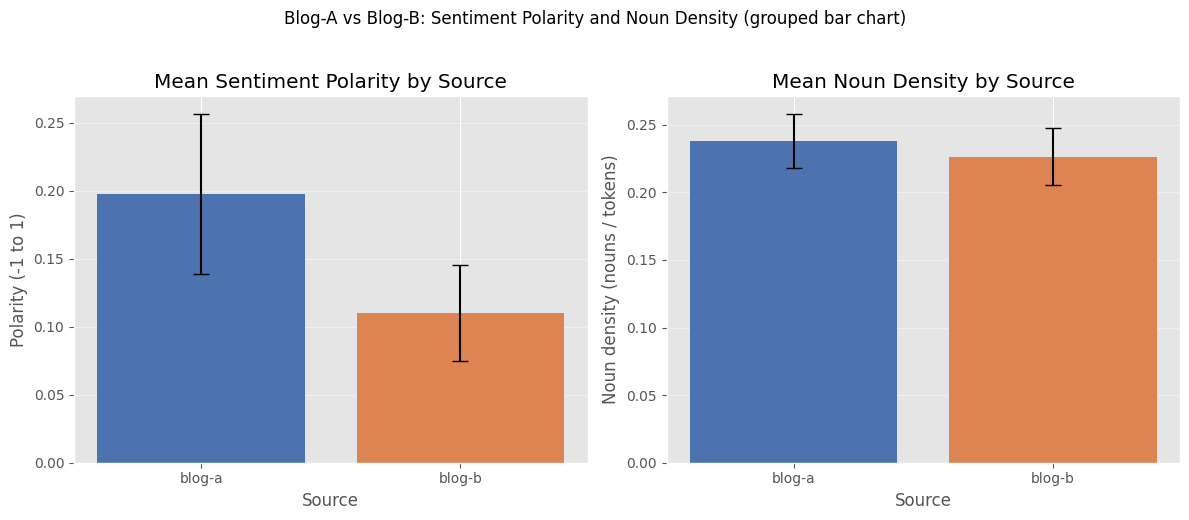

In [19]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title, ylabel in zip(
    axes,
    ['sentiment_polarity', 'noun_density'],
    ['Mean Sentiment Polarity by Source', 'Mean Noun Density by Source'],
    ['Polarity (-1 to 1)', 'Noun density (nouns / tokens)']
):
    means = corpus.groupby('source')[col].mean()
    stds = corpus.groupby('source')[col].std()
    ax.bar(means.index, means.values, yerr=stds.values, capsize=6,
           color=['#4C72B0', '#DD8452'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Source')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Blog-A vs Blog-B: Sentiment Polarity and Noun Density (grouped bar chart)', y=1.03)
plt.tight_layout()
plt.savefig('figures/06_home_assignment_grouped_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation — is a difference of this size meaningful at n = 10 per group?

Numerically, blog-a (marketing/tools blog) shows a higher mean sentiment polarity than blog-b
(technical ML blog) — consistent with promotional writing skewing positive versus explanatory
technical writing staying neutral — while noun density is closer between the two, since both are
prose-heavy, noun-dense technical/how-to writing rather than narrative text.

Whether either difference is **meaningful**, though, depends on more than the raw gap: with only
10 articles per source, the standard error of a mean is large relative to the natural
article-to-article variability in polarity and noun density (some posts are lists, some are
reviews, some are tutorials, and that variability alone can produce differences of a similar
magnitude by chance). The Welch $t$-tests above give the honest answer: treat a result significant
at the conventional $\alpha = 0.05$ threshold ($p < 0.05$) as evidence the sources genuinely
differ on that metric, and treat a larger $p$-value as "not distinguishable from chance at this
sample size" rather than "no difference exists" — a non-significant result with $n=10$ per group
has fairly low statistical power to detect anything but a large effect. In either case, 10
articles per blog is a convenience sample (whatever the blog happened to have published), not a
random sample of "all possible articles" from each source, so even a significant $p$-value
describes *these twenty articles*, not a guaranteed property of the two blogs going forward — a
useful, well-quantified pilot result rather than a definitive population-level claim.

---

# Deliverables

| File | Contents |
|---|---|
| `lab02/scraping_eda.ipynb` | This notebook, executed, with all outputs visible |
| `lab02/articles.csv` | The scraped corpus with all engineered features |
| `lab02/figures/*.png` | The figures exported as PNG |
| `lab02/report.md` | The NumPy timing comparison, the EDA findings and the TF–IDF interpretation |

## Assessment Rubric

| Criterion | Weight | Excellent performance |
|---|---|---|
| Correctness of implementation | 35 % | Scraper handles failures gracefully; features computed correctly |
| Methodological soundness | 25 % | Server treated politely; sample-size limits acknowledged |
| Analysis and interpretation | 20 % | Figures are *read*, not merely produced |
| Code quality and reproducibility | 10 % | Raw scrape cached; functions reusable |
| Report and demonstration | 10 % | Clear written report and working demonstration |

---

**Next laboratory:** Lab 03 — Transforming Textual and Image Data into a Machine-Understandable Format.